<a href="https://colab.research.google.com/github/sunandha2/Urban-Mobility-Intelligence-Uber-Analysis/blob/main/Uber_Pickup_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
df = pd.read_csv("uber-raw-data-apr14[1].csv") # to load data
df.head()# show first rows

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [16]:
import os
os.listdir()

['.config', '.ipynb_checkpoints', 'uber-raw-data-apr14[1].csv']

In [17]:
df.info() # to understaan the data
df.describe() # to understand basic statistics


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  564516 non-null  object 
 1   Lat        564516 non-null  float64
 2   Lon        564516 non-null  float64
 3   Base       564516 non-null  object 
dtypes: float64(2), object(2)
memory usage: 17.2+ MB


,Lat,Lon
count,564516.000000,564516.000000
mean,40.740005,-73.976817
std,0.036083,0.050426
min,40.072900,-74.773300
25%,40.722500,-73.997700
50%,40.742500,-73.984800
75%,40.760700,-73.970000
max,42.116600,-72.066600


In [18]:
df.columns

Index(['Date/Time', 'Lat', 'Lon', 'Base'], dtype='object')

In [19]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'])
# to covert to datetime type

In [23]:
df['hour'] = df['Date/Time'].dt.hour
df['day'] = df['Date/Time'].dt.day
df['weekday'] = df['Date/Time'].dt.weekday

STEP 1: Trips by Hour (Peak Detection)

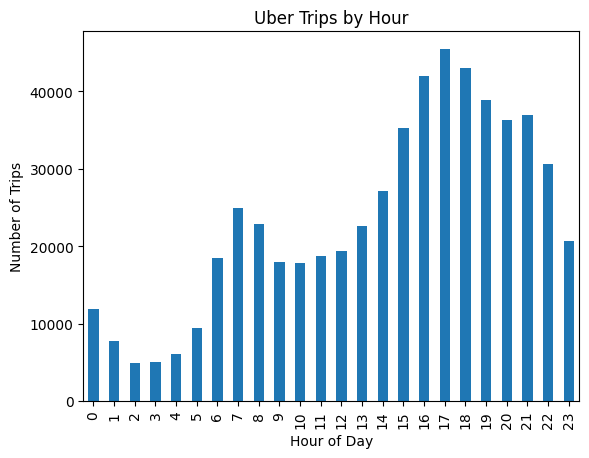

In [21]:
import matplotlib.pyplot as plt

hour_counts = df['hour'].value_counts().sort_index()

hour_counts.plot(kind='bar')
plt.title("Uber Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

Insight:
Uber demand peaks during evening hours, indicating increased ride usage during post-work commuting time.

STEP 2: Trips by Weekday

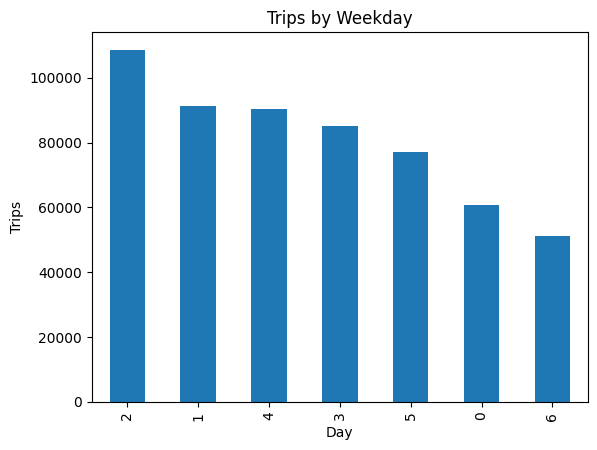

In [22]:
df['weekday'].value_counts().plot(kind='bar')
plt.title("Trips by Weekday")
plt.xlabel("Day")
plt.ylabel("Trips")
plt.show()

Insight:
wednesday show higher demand in weekdays and saturday show higher demand in weekend with monday and sunday having lower demand comparatively

STEP 3: Heatmap

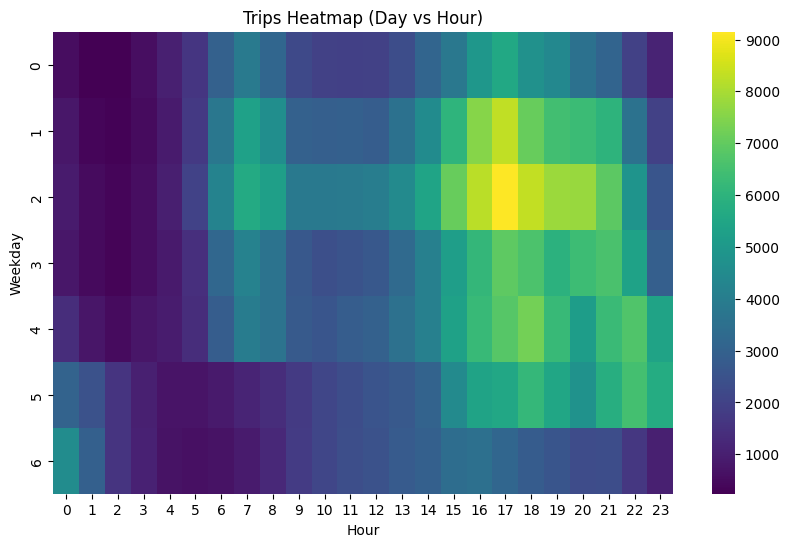

In [24]:
import seaborn as sns

pivot = df.groupby(['weekday', 'hour']).size().unstack()

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap='viridis')

plt.title("Trips Heatmap (Day vs Hour)")
plt.xlabel("Hour")
plt.ylabel("Weekday")
plt.show()

Base Analysis

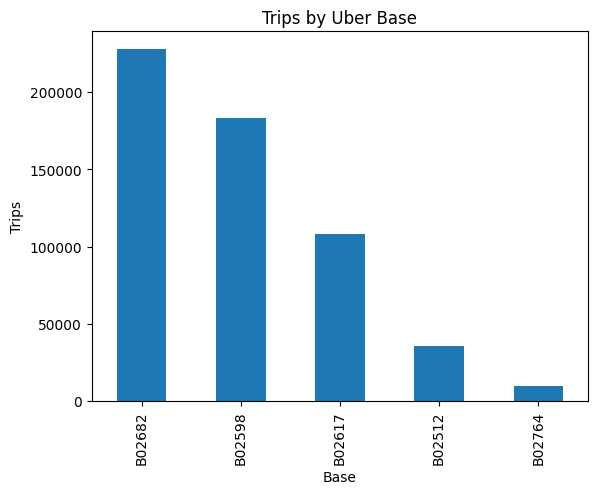

In [25]:
df['Base'].value_counts().plot(kind='bar')
plt.title("Trips by Uber Base")
plt.xlabel("Base")
plt.ylabel("Trips")
plt.show()

The concentration of demand during evening hours suggests an opportunity for dynamic pricing and driver allocation strategies to optimize supply during peak periods.

### Key Insights:
1. Peak demand occurs during 4 PM – 7 PM.
2. Weekdays show sharp commute-driven spikes.
3. Weekend demand is more evenly distributed.
4. Late-night usage increases slightly on weekends.
5. Opportunity for surge pricing and driver optimization during peak hours.